# MAE versus interval width

This notebook loads saved prediction intervals and plots point-forecast MAE across interval-width deciles.

In [59]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

RESULT_ROOT = Path('/home/dy23a.fsu/st/result')
FIGURE_DIR = RESULT_ROOT / 'figures'
SAVE_FIGURE = False
MAX_SAMPLES = 500_000
RANDOM_SEED = 2026
COMPONENT_ORDER = 'auto'  # 'auto', 'flow_cqr', or 'od_cqr'

SELECTIONS = [
    dict(project='NYC_OD', model='PDR_CQR', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*od_cqr_od_split_cp_horizon_res.npy', label='PDR'),
    dict(project='NYC_OD', model='PDR_REG_POST', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*zero_cqr_8bin_res*.npy', label='ZeroCQR (PDR)'),
    dict(project='NYC_OD', model='AGCRN_OD_CQR', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*od_cqr_od_split_cp_horizon_res.npy', label='AGCRN'),
    dict(project='NYC_OD', model='STGCN_OD_CQR', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*od_cqr_od_split_cp_horizon_res.npy', label='STGCN'),
    dict(project='NYC_OD', model='GWNET_OD_CQR', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*od_cqr_od_split_cp_horizon_res.npy', label='GWNET'),
    dict(project='NYC_OD', model='GMEL_CQR', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*od_cqr_od_split_cp_horizon_res.npy', label='GMEL'),
]

DAILY_PROFILE_SELECTIONS = [
    dict(project='NYC_OD', model='PDR_REG_POST', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*zero_cqr_32bin_res*.npy', label='ZeroCQR', color='#2ca25f', interval=True, linestyle='-'),
    dict(project='NYC_OD', model='STZINB_CQR', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*od_cqr_od_split_cp_horizon_res.npy', label='STZINB', color='#2171b5', interval=True, linestyle='-'),
    dict(project='NYC_OD', model='PDR_CQR', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*od_cqr_od_split_cp_horizon_res.npy', label='PDR', color='#54278f', interval=False, linestyle='--'),
    dict(project='NYC_OD', model='AGCRN_OD_CQR', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*od_cqr_od_split_cp_horizon_res.npy', label='AGCRN', color='#e6550d', interval=False, linestyle='--'),
    dict(project='NYC_OD', model='GWNET_OD_CQR', dataset='nyc_manhattan_od_15min_fhv',
         pattern='*od_cqr_od_split_cp_horizon_res.npy', label='GWNET', color='#756bb1', interval=False, linestyle='--'),
]
STEPS_PER_DAY = 24 * 4
DAY_START_OFFSET = 0  # Number of 15-min test steps before the first plotted midnight.


In [60]:
def resolve_selection(selection):
    directory = RESULT_ROOT / selection['project'] / selection['model'] / selection['dataset']
    matches = sorted(directory.glob(selection.get('pattern', '*res*.npy')), key=lambda path: path.stat().st_mtime)
    if not matches:
        raise FileNotFoundError(f"No result matched {directory / selection.get('pattern', '*res*.npy')}")
    return matches[-1], selection['label']

@dataclass
class IntervalData:
    label: str
    point: np.ndarray
    lower: np.ndarray
    upper: np.ndarray
    target: np.ndarray

def _order_score(point, lower, upper):
    finite = np.isfinite(point) & np.isfinite(lower) & np.isfinite(upper)
    return np.mean((lower[finite] <= point[finite]) & (point[finite] <= upper[finite])) if finite.any() else -np.inf

def interval_component_indices(raw):
    probe = np.arange(min(10_000, int(np.prod(raw.shape[1:]))))
    candidates = {
        'flow_cqr': (raw[1].reshape(-1)[probe], raw[0].reshape(-1)[probe], raw[2].reshape(-1)[probe]),
        'od_cqr': (raw[0].reshape(-1)[probe], raw[1].reshape(-1)[probe], raw[2].reshape(-1)[probe]),
    }
    order = max(candidates, key=lambda key: _order_score(*candidates[key])) if COMPONENT_ORDER == 'auto' else COMPONENT_ORDER
    if order not in candidates:
        raise ValueError("COMPONENT_ORDER must be 'auto', 'flow_cqr', or 'od_cqr'.")
    return {'flow_cqr': (1, 0, 2), 'od_cqr': (0, 1, 2)}[order]

def load_interval_result(path, label):
    raw = np.load(path, mmap_mode='r')
    if raw.ndim < 2 or raw.shape[0] < 4:
        raise ValueError(f'{path.name} is not a four-component interval export; found shape {raw.shape}.')
    total = int(np.prod(raw.shape[1:]))
    take = total if MAX_SAMPLES is None else min(total, MAX_SAMPLES)
    rng = np.random.default_rng(RANDOM_SEED)
    indices = np.arange(total) if take == total else rng.choice(total, size=take, replace=False)

    point_index, lower_index, upper_index = interval_component_indices(raw)
    point = np.asarray(raw[point_index].reshape(-1)[indices], dtype=float)
    lower = np.asarray(raw[lower_index].reshape(-1)[indices], dtype=float)
    upper = np.asarray(raw[upper_index].reshape(-1)[indices], dtype=float)
    target = np.asarray(raw[3].reshape(-1)[indices], dtype=float)
    valid = np.isfinite(point) & np.isfinite(lower) & np.isfinite(upper) & np.isfinite(target) & (upper >= lower)
    return IntervalData(label, point[valid], lower[valid], upper[valid], target[valid])


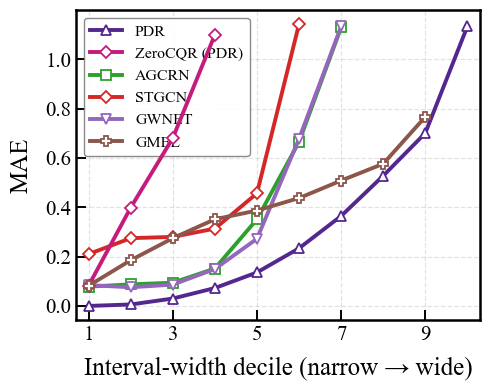

In [61]:
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
MARKERS = ['^', 'o', 's', 'D', 'v', 'P']

def method_style(label, index):
    name = label.lower()
    if 'zero' in name:
        return dict(color='#c51b7d', marker='D', zorder=8)
    if 'pdr' in name:
        return dict(color='#54278f', marker='^', zorder=7)
    return dict(color=COLORS[index % len(COLORS)], marker=MARKERS[index % len(MARKERS)], zorder=3 + index)

def width_decile_mae(data, bins=10):
    width = data.upper - data.lower
    edges = np.unique(np.quantile(width, np.linspace(0, 1, bins + 1)))
    group = np.clip(np.digitize(width, edges[1:-1], right=True), 0, len(edges) - 2)
    x = np.arange(len(edges) - 1) + 1
    mae = np.array([np.mean(np.abs(data.target[group == j] - data.point[group == j])) for j in range(len(x))])
    return x, mae

def plot_mae_vs_interval_width(datasets):
    fig, ax = plt.subplots(figsize=(5, 4))
    for index, data in enumerate(datasets):
        x, mae = width_decile_mae(data)
        ax.plot(x, mae, markerfacecolor='white', markeredgewidth=1.3, ms=6.5, lw=2.8,
                label=data.label, **method_style(data.label, index))
    ax.set_xlim(.7, 10.3)
    ax.set_xticks(np.arange(1, 11, 2))
    ax.set_xlabel('Interval-width decile (narrow → wide)', fontsize=18, fontweight='bold', labelpad=8)
    ax.set_ylabel('MAE', fontsize=18, fontweight='bold', labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=15, direction='in', length=7, width=1.4)
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.grid(True, linestyle='--', linewidth=.9, alpha=.35, zorder=0)
    ax.legend(fontsize=11.5, loc='best', frameon=True, framealpha=.92, edgecolor='gray')
    fig.tight_layout()
    return fig

datasets = [load_interval_result(*resolve_selection(selection)) for selection in SELECTIONS]
fig = plot_mae_vs_interval_width(datasets)
if SAVE_FIGURE:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_DIR / 'mae_vs_interval_width.pdf', bbox_inches='tight')
plt.show()


# Average daily prediction profile

Each curve averages all OD pairs and all complete test days at the same 15-minute slot.

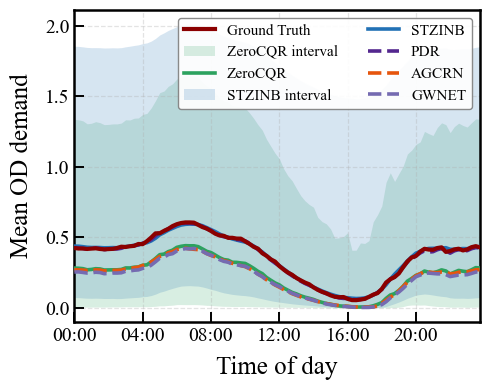

In [62]:
def load_daily_profile(path, label):
    raw = np.load(path, mmap_mode='r')
    if raw.ndim < 3 or raw.shape[0] < 4 or raw.shape[2] != 1:
        raise ValueError(f'{path.name} must contain one forecast horizon per test step; found shape {raw.shape}.')
    point_index, lower_index, upper_index = interval_component_indices(raw)
    # Average all OD pairs, retaining the chronological test-step axis.
    reduce_axes = tuple(range(1, raw.ndim - 1))
    point = np.asarray(raw[point_index].mean(axis=reduce_axes), dtype=float)
    lower = np.asarray(raw[lower_index].mean(axis=reduce_axes), dtype=float)
    upper = np.asarray(raw[upper_index].mean(axis=reduce_axes), dtype=float)
    target = np.asarray(raw[3].mean(axis=reduce_axes), dtype=float)
    start = DAY_START_OFFSET % STEPS_PER_DAY
    usable = ((len(point) - start) // STEPS_PER_DAY) * STEPS_PER_DAY
    if usable == 0:
        raise ValueError('The exported test sequence does not contain one complete day after DAY_START_OFFSET.')
    def daily_mean(values):
        return values[start:start + usable].reshape(-1, STEPS_PER_DAY).mean(axis=0)
    return dict(label=label, point=daily_mean(point), lower=daily_mean(lower),
                upper=daily_mean(upper), target=daily_mean(target))

def plot_average_daily_profile(profiles):
    fig, ax = plt.subplots(figsize=(5, 4))
    x = np.arange(STEPS_PER_DAY)
    reference = profiles[0]['target']
    for profile in profiles[1:]:
        if not np.allclose(reference, profile['target'], equal_nan=True):
            raise ValueError('The selected methods do not share the same ground-truth test sequence.')
    ax.plot(x, reference, color='#8b0000', lw=3.0, label='Ground Truth', zorder=5)
    for profile, selection in zip(profiles, DAILY_PROFILE_SELECTIONS):
        if selection['interval']:
            ax.fill_between(x, profile['lower'], profile['upper'], color=selection['color'], alpha=.18, linewidth=0,
                            label=f"{profile['label']} interval", zorder=1)
        ax.plot(x, profile['point'], color=selection['color'], linestyle=selection['linestyle'], lw=2.6,
                label=profile['label'], zorder=4)
    ticks = np.arange(0, STEPS_PER_DAY + 1, 16)
    ax.set_xticks(ticks, [f'{hour:02d}:00' for hour in range(0, 25, 4)])
    ax.set_xlim(0, STEPS_PER_DAY - 1)
    ax.set_xlabel('Time of day', fontsize=18, fontweight='bold', labelpad=8)
    ax.set_ylabel('Mean OD demand', fontsize=18, fontweight='bold', labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=14, direction='in', length=7, width=1.4)
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.grid(True, linestyle='--', linewidth=.9, alpha=.35, zorder=0)
    ax.legend(fontsize=11, ncol=2, loc='upper right', frameon=True, framealpha=.92, edgecolor='gray')
    fig.tight_layout()
    return fig

daily_profile_files = [resolve_selection(selection) for selection in DAILY_PROFILE_SELECTIONS]
daily_profiles = [load_daily_profile(path, label) for path, label in daily_profile_files]
fig_daily = plot_average_daily_profile(daily_profiles)
if SAVE_FIGURE:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig_daily.savefig(FIGURE_DIR / 'average_daily_prediction_profile.pdf', bbox_inches='tight')
plt.show()


# Cell-level MAE comparison

These diagnostics aggregate absolute errors, rather than predictions. Consequently, positive and negative errors cannot cancel.

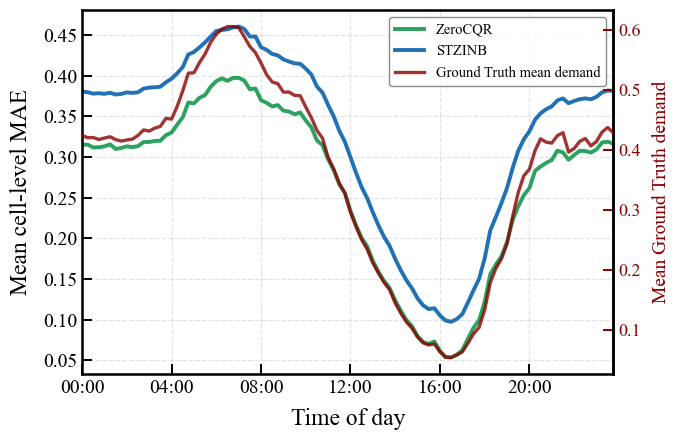

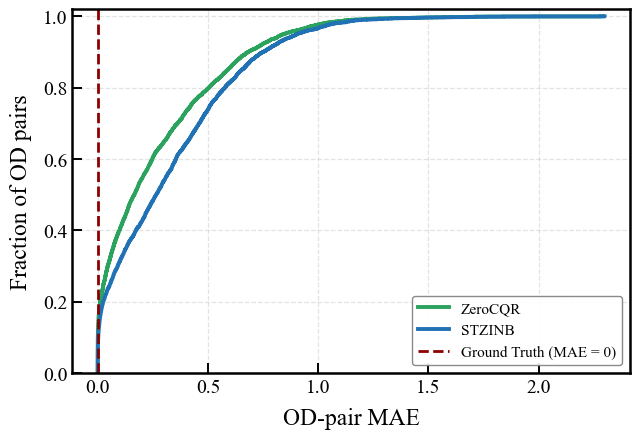

In [63]:
ERROR_COMPARISON_SELECTIONS = DAILY_PROFILE_SELECTIONS[:2]  # ZeroCQR and STZINB

def load_error_diagnostics(path, label):
    raw = np.load(path, mmap_mode='r')
    point_index, _, _ = interval_component_indices(raw)
    point = np.asarray(raw[point_index], dtype=float)
    target = np.asarray(raw[3], dtype=float)
    absolute_error = np.abs(point - target)
    # `absolute_error` has dimensions (test step, horizon, origin, destination, channel).
    mean_error_per_step = absolute_error.mean(axis=tuple(range(1, absolute_error.ndim)))
    start = DAY_START_OFFSET % STEPS_PER_DAY
    usable = ((len(mean_error_per_step) - start) // STEPS_PER_DAY) * STEPS_PER_DAY
    if usable == 0:
        raise ValueError('The exported test sequence does not contain one complete day after DAY_START_OFFSET.')
    daily_mae = mean_error_per_step[start:start + usable].reshape(-1, STEPS_PER_DAY).mean(axis=0)
    pair_mae = absolute_error.mean(axis=tuple(range(0, absolute_error.ndim - 3))).squeeze(-1)
    mean_target_per_step = target.mean(axis=tuple(range(1, target.ndim)))
    daily_target = mean_target_per_step[start:start + usable].reshape(-1, STEPS_PER_DAY).mean(axis=0)
    return dict(label=label, daily_mae=daily_mae, pair_mae=pair_mae, daily_target=daily_target)

def style_error_axis(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, fontsize=17, fontweight='bold', labelpad=8)
    ax.set_ylabel(ylabel, fontsize=17, fontweight='bold', labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=14, direction='in', length=7, width=1.4)
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.grid(True, linestyle='--', linewidth=.9, alpha=.35, zorder=0)

def plot_daily_cell_mae(diagnostics):
    fig, ax = plt.subplots(figsize=(6.8, 4.5))
    x = np.arange(STEPS_PER_DAY)
    for diagnostic, selection in zip(diagnostics, ERROR_COMPARISON_SELECTIONS):
        ax.plot(x, diagnostic['daily_mae'], color=selection['color'], lw=2.8, label=diagnostic['label'])
    ticks = np.arange(0, STEPS_PER_DAY + 1, 16)
    ax.set_xticks(ticks, [f'{hour:02d}:00' for hour in range(0, 25, 4)])
    ax.set_xlim(0, STEPS_PER_DAY - 1)
    style_error_axis(ax, 'Time of day', 'Mean cell-level MAE')
    target_ax = ax.twinx()
    target_line = target_ax.plot(x, diagnostics[0]['daily_target'], color='#8b0000', lw=2.4, alpha=.8,
                                 label='Ground Truth mean demand', zorder=3)[0]
    target_ax.set_ylabel('Mean Ground Truth demand', color='#8b0000', fontsize=14, fontweight='bold', labelpad=8)
    target_ax.tick_params(axis='y', labelsize=13, colors='#8b0000', direction='in', length=7, width=1.4)
    target_ax.spines['right'].set_linewidth(1.8)
    lines, labels = ax.get_legend_handles_labels()
    ax.legend(lines + [target_line], labels + [target_line.get_label()], fontsize=10.5, loc='best',
              frameon=True, framealpha=.92, edgecolor='gray')
    fig.tight_layout()
    return fig

def plot_pair_mae_ecdf(diagnostics):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    for diagnostic, selection in zip(diagnostics, ERROR_COMPARISON_SELECTIONS):
        values = np.sort(diagnostic['pair_mae'][np.isfinite(diagnostic['pair_mae'])].ravel())
        ecdf = np.arange(1, len(values) + 1) / len(values)
        ax.step(values, ecdf, where='post', color=selection['color'], lw=2.8, label=diagnostic['label'])
    style_error_axis(ax, 'OD-pair MAE', 'Fraction of OD pairs')
    ax.axvline(0, color='#8b0000', lw=2.0, ls='--', label='Ground Truth (MAE = 0)')
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=11, loc='lower right', frameon=True, framealpha=.92, edgecolor='gray')
    fig.tight_layout()
    return fig

error_files = [resolve_selection(selection) for selection in ERROR_COMPARISON_SELECTIONS]
error_diagnostics = [load_error_diagnostics(path, label) for path, label in error_files]
fig_daily_mae = plot_daily_cell_mae(error_diagnostics)
fig_pair_ecdf = plot_pair_mae_ecdf(error_diagnostics)
if SAVE_FIGURE:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig_daily_mae.savefig(FIGURE_DIR / 'daily_cell_level_mae.pdf', bbox_inches='tight')
    fig_pair_ecdf.savefig(FIGURE_DIR / 'od_pair_mae_ecdf.pdf', bbox_inches='tight')
plt.show()
